# Day 4 – Data Visualisation & Power BI

**Duration:** 5 hours  
**Date:** 03-Sep-2026  
**Focus:** Matplotlib, Seaborn, Power BI Essentials, Interactive Dashboard & Storytelling

## Learning Objectives

By the end of Day 4, you will be able to:

- Choose an appropriate chart for a business question.
- Create and customize charts using Matplotlib.
- Create statistical and analytical plots using Seaborn.
- Build a 4-chart visual summary using subplots.
- Understand the Power BI Desktop interface.
- Understand Power Query, data modelling and basic DAX.
- Design an interactive Power BI dashboard with KPIs, slicers and drill-through.
- Communicate data insights as a business story.

> **Important:** Python visualisation is completed in this notebook. Power BI is a separate desktop application; the Power BI section below gives the exact practical workflow, sample tables, DAX and dashboard checklist.

## Day 4 Schedule

| Time | Block | Focus |
|---|---|---|
| 09:30–10:00 | B1 | Day 3 recap, chart critique and objectives |
| 10:00–11:15 | B2 | Matplotlib & Seaborn |
| 11:15–11:25 | Break | — |
| 11:25–12:30 | B3 | Power BI Essentials |
| 12:30–13:30 | Lunch | Excluded |
| 13:30–15:00 | B4 | Interactive Business Dashboard Lab |
| 15:00–15:30 | B5 | Presentation, checkpoint and wrap-up |

# B1 – Recap & Objectives

## EDA Workflow

```text
Load Data
   ↓
Understand Data
   ↓
Clean Data
   ↓
Descriptive Statistics
   ↓
Visualise
   ↓
Find Patterns / Outliers / Relationships
   ↓
Communicate Insights
```

### Describe vs Persuade

A **descriptive** chart tells us what is in the data.

A **persuasive** chart is designed to make the important message easy to understand.

### Chart Critique Activity

Look at a chart and ask:

1. Is the title clear?
2. Are the axes labelled?
3. Is the chart type suitable?
4. Are colours helping or distracting?
5. Is there unnecessary chart decoration?
6. Can the main message be understood quickly?

**Student task:** Critique three charts and identify at least one design problem in each.

# B2 – Matplotlib & Seaborn

## Matplotlib Architecture

The main objects are:

```text
Figure
  └── Axes
        ├── plot
        ├── title
        ├── labels
        └── annotations
```

The object-oriented API is useful when a figure contains multiple charts because each `Axes` object can be controlled separately.

In [ ]:
# Run this once if required:
# %pip install pandas numpy matplotlib seaborn

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries loaded successfully")

Libraries loaded successfully


## Create a Practice Dataset

This notebook creates a small, reproducible business dataset so that every chart can be run without downloading a file.

Columns include:

- Date
- Product
- Category
- Region
- Sales
- Profit
- Quantity
- CustomerAge

In [9]:
np.random.seed(42)

n = 300

products = ["Laptop", "Phone", "Tablet", "Chair", "Desk"]
categories = {
    "Laptop": "Electronics",
    "Phone": "Electronics",
    "Tablet": "Electronics",
    "Chair": "Furniture",
    "Desk": "Furniture"
}
regions = ["North", "South", "East", "West"]

df = pd.DataFrame({
    "Date": pd.date_range("2026-01-01", periods=n, freq="D"),
    "Product": np.random.choice(products, n),
    "Region": np.random.choice(regions, n),
    "Quantity": np.random.randint(1, 10, n),
    "CustomerAge": np.random.randint(20, 61, n)
})

df["Category"] = df["Product"].map(categories)
df["Sales"] = np.random.randint(500, 10000, n)
df["Profit"] = (df["Sales"] * np.random.uniform(0.05, 0.30, n)).round(2)

df.head()

,Date,Product,Region,Quantity,CustomerAge,Category,Sales,Profit
0,2026-01-01,Chair,North,7,41,Furniture,3038,808.48
1,2026-01-02,Desk,West,5,40,Furniture,5047,1178.36
2,2026-01-03,Tablet,North,1,25,Electronics,6119,1103.35
3,2026-01-04,Desk,North,7,25,Furniture,8856,2364.91
4,2026-01-05,Desk,South,7,23,Furniture,7112,791.72


In [12]:
# Basic Day 3-style checks
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nStatistics:")
display(df.describe(numeric_only=True))

Shape: (300, 8)

Missing values:
Date           0
Product        0
Region         0
Quantity       0
CustomerAge    0
Category       0
Sales          0
Profit         0
dtype: int64

Statistics:


TypeError: NDFrame.describe() got an unexpected keyword argument 'numeric_only'

## 1. Line Chart – Trend

**Use when:** the question is about change over time.

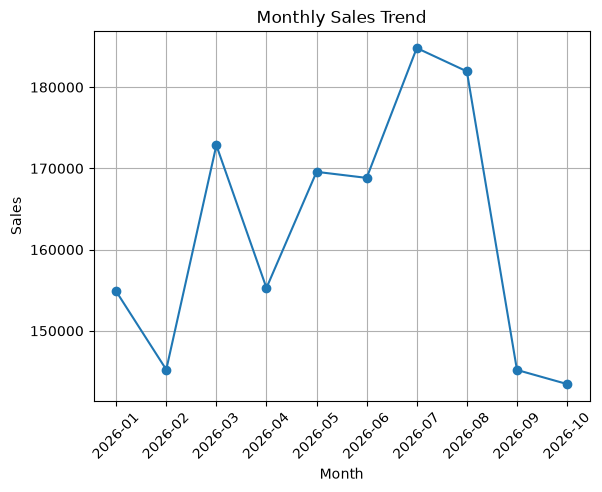

In [13]:
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Sales"].sum()

plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## 2. Bar Chart – Comparison

**Use when:** comparing categories or groups.

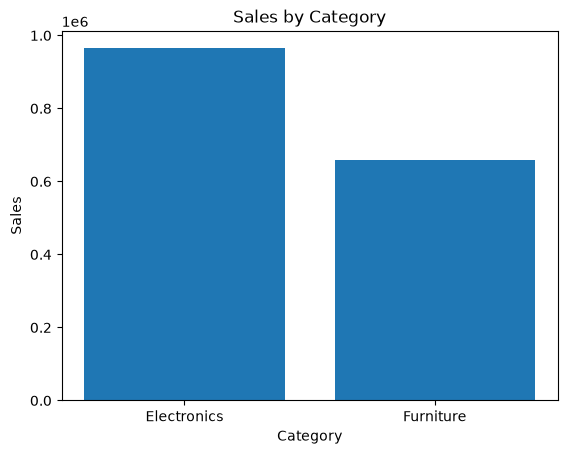

In [14]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.bar(category_sales.index, category_sales.values)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

## 3. Horizontal Bar Chart

Horizontal bars are useful when category names are long.

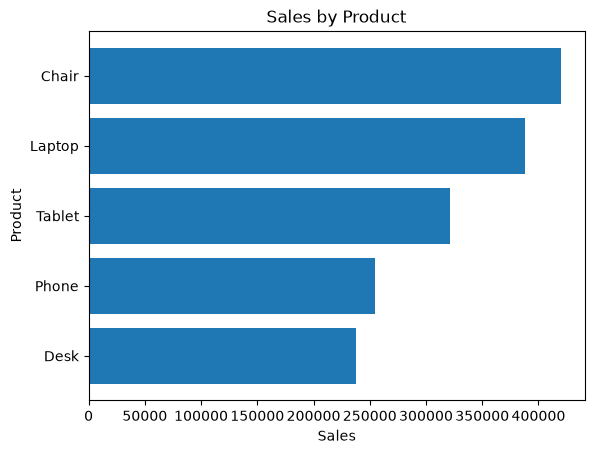

In [15]:
product_sales = df.groupby("Product")["Sales"].sum().sort_values()

plt.barh(product_sales.index, product_sales.values)
plt.title("Sales by Product")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

## 4. Histogram – Distribution

**Use when:** understanding how numerical values are distributed.

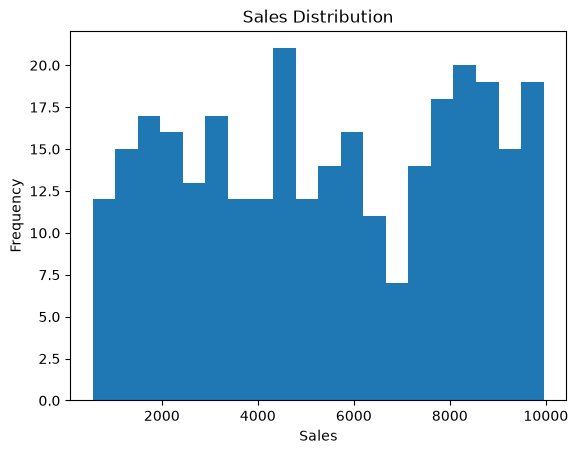

In [16]:
plt.hist(df["Sales"], bins=20)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

## 5. Scatter Plot – Relationship

**Use when:** checking the relationship between two numerical variables.

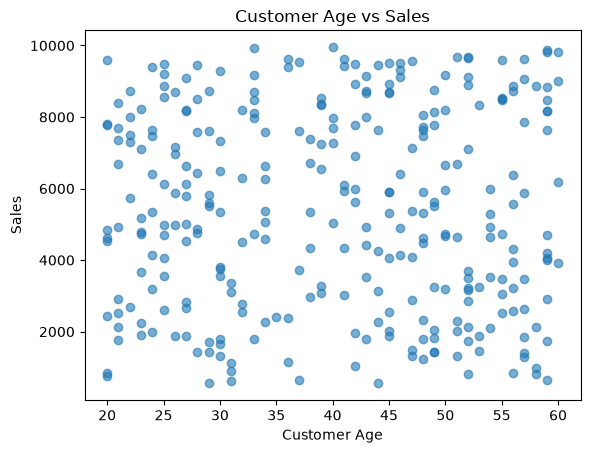

In [17]:
plt.scatter(df["CustomerAge"], df["Sales"], alpha=0.6)
plt.title("Customer Age vs Sales")
plt.xlabel("Customer Age")
plt.ylabel("Sales")
plt.show()

## 6. Pie Chart – Composition

Pie charts should be used sparingly and only when the number of categories is small.

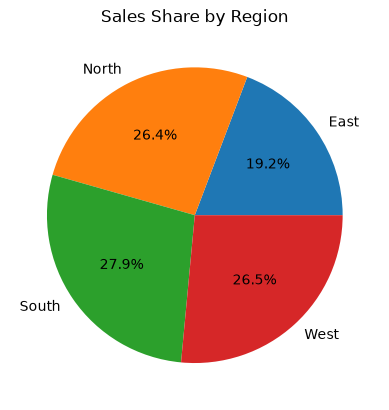

In [18]:
region_sales = df.groupby("Region")["Sales"].sum()

plt.pie(region_sales, labels=region_sales.index, autopct="%1.1f%%")
plt.title("Sales Share by Region")
plt.show()

## Matplotlib Customisation

Common tools:

```python
plt.title()
plt.xlabel()
plt.ylabel()
plt.legend()
plt.grid()
plt.annotate()
plt.xticks()
plt.yticks()
```

Good practice:

- Use a meaningful title.
- Label axes.
- Avoid unnecessary decoration.
- Keep formatting consistent.
- Highlight the important message.

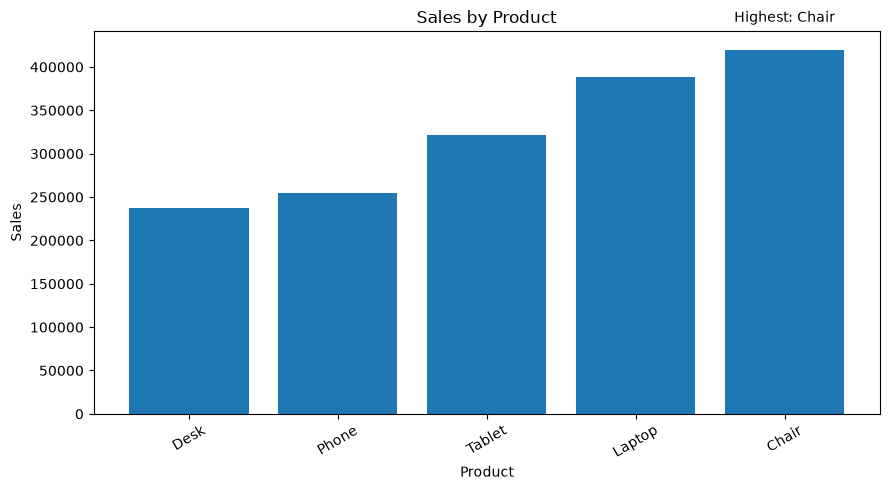

In [19]:
top_product = product_sales.idxmax()
top_value = product_sales.max()

plt.figure(figsize=(9, 5))
plt.bar(product_sales.index, product_sales.values)
plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=30)

plt.annotate(
    f"Highest: {top_product}",
    xy=(list(product_sales.index).index(top_product), top_value),
    xytext=(0, 20),
    textcoords="offset points",
    ha="center"
)

plt.tight_layout()
plt.show()

## Subplots – 4-Panel Visual Summary

A subplot dashboard can show four different views of the same dataset:

1. Trend
2. Distribution
3. Comparison
4. Correlation

The object-oriented API makes this easier to manage.

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# 1. Trend
ax[0, 0].plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o")
ax[0, 0].set_title("Sales Trend")
ax[0, 0].tick_params(axis="x", rotation=45)

# 2. Distribution
ax[0, 1].hist(df["Sales"], bins=20)
ax[0, 1].set_title("Sales Distribution")

# 3. Comparison
ax[1, 0].bar(category_sales.index, category_sales.values)
ax[1, 0].set_title("Sales by Category")
ax[1, 0].tick_params(axis="x", rotation=20)

# 4. Relationship
ax[1, 1].scatter(df["CustomerAge"], df["Sales"], alpha=0.5)
ax[1, 1].set_title("Age vs Sales")

fig.suptitle("Business Visual Summary", fontsize=16)
plt.tight_layout()
plt.show()

## Save a Figure at Good Quality

For reports or presentations, save figures at higher resolution.

```python
plt.savefig("filename.png", dpi=300, bbox_inches="tight")
```

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(category_sales.index, category_sales.values)
ax.set_title("Sales by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Sales")
plt.tight_layout()

fig.savefig("sales_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: sales_by_category.png")

# Seaborn

Seaborn works with Matplotlib and provides a convenient interface for statistical visualisation.

Set a simple theme before plotting:

In [ ]:
sns.set_style("whitegrid")

## 7. Seaborn Histogram

In [ ]:
sns.histplot(data=df, x="Sales", bins=20)
plt.title("Sales Distribution")
plt.show()

## 8. KDE Plot

KDE gives a smooth view of a distribution.

In [ ]:
sns.kdeplot(data=df, x="Sales", fill=True)
plt.title("Sales Density")
plt.show()

## 9. Boxplot – Outliers

Boxplots are useful for comparing distributions and spotting potential outliers.

In [ ]:
sns.boxplot(data=df, x="Category", y="Sales")
plt.title("Sales Distribution by Category")
plt.xticks(rotation=20)
plt.show()

## 10. Violin Plot

A violin plot combines distribution shape with a compact statistical view.

In [ ]:
sns.violinplot(data=df, x="Category", y="Sales")
plt.title("Sales Distribution by Category")
plt.xticks(rotation=20)
plt.show()

## 11. Countplot

Use `countplot` to count observations in categories.

In [ ]:
sns.countplot(data=df, x="Region")
plt.title("Number of Transactions by Region")
plt.show()

## 12. Barplot

A Seaborn barplot summarizes a numerical variable for categories. By default it can show an estimate with a confidence interval.

In [ ]:
sns.barplot(data=df, x="Category", y="Sales")
plt.title("Average Sales by Category")
plt.xticks(rotation=20)
plt.show()

## 13. Scatterplot with `hue`

Colour can represent another category.

In [ ]:
sns.scatterplot(
    data=df,
    x="CustomerAge",
    y="Sales",
    hue="Category"
)
plt.title("Age vs Sales by Category")
plt.show()

## Scatterplot with `size` and `style`

Multiple visual encodings can add information, but avoid making a chart too complicated.

In [ ]:
sns.scatterplot(
    data=df,
    x="CustomerAge",
    y="Sales",
    hue="Region",
    size="Quantity",
    style="Category"
)
plt.title("Sales Relationship by Region and Category")
plt.show()

## 14. Regression Plot

A regression plot helps show a simple linear relationship.

In [ ]:
sns.regplot(data=df, x="CustomerAge", y="Sales")
plt.title("Age vs Sales with Trend Line")
plt.show()

## 15. Correlation Heatmap

Correlation is useful for understanding relationships among numerical variables.

A correlation close to:

- `+1` → strong positive relationship
- `0` → little/no linear relationship
- `-1` → strong negative relationship

In [ ]:
numeric_df = df[["Sales", "Profit", "Quantity", "CustomerAge"]]
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 16. Pairplot

`pairplot` gives a quick view of relationships between several numerical variables.

Use it for exploration rather than as the final business dashboard.

In [ ]:
sns.pairplot(
    df[["Sales", "Profit", "Quantity", "CustomerAge"]]
)
plt.show()

## Chart Selection Guide

| Business Question | Recommended Chart |
|---|---|
| What is the trend over time? | Line chart |
| Which category is highest? | Bar chart |
| How are values distributed? | Histogram / KDE |
| Are there outliers? | Boxplot |
| What is the relationship between two numbers? | Scatterplot |
| How many records are in each category? | Countplot |
| How are numerical variables related? | Heatmap |
| How do several numerical variables relate? | Pairplot |
| What is the composition of a small number of groups? | Pie / Donut |

# Student Exercise – 4-Chart Visual Summary

Using the `df` dataset, create your own 2 × 2 visual summary.

### Required charts

- Trend chart
- Distribution chart
- Comparison chart
- Relationship or correlation chart

### Requirements

- Clear title
- Axis labels
- Readable font size
- Appropriate chart type
- Consistent formatting
- No unnecessary chart decoration

### Your observations

Write at least **4 business observations** below the charts.

In [ ]:
# YOUR TASK
# Replace the examples below with your own 4-chart visual summary.

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Chart 1: Trend
# ax[0, 0].plot(...)

# Chart 2: Distribution
# ax[0, 1].hist(...)

# Chart 3: Comparison
# ax[1, 0].bar(...)

# Chart 4: Relationship
# ax[1, 1].scatter(...)

fig.suptitle("My 4-Chart Business Summary", fontsize=16)
plt.tight_layout()
plt.show()

# B3 – Power BI Essentials

## Power BI Desktop Views

Power BI Desktop has three important views:

```text
Report View → build visuals and dashboards
Data View   → inspect table data
Model View  → manage tables and relationships
```

## Data Sources

Common sources include:

- Excel
- CSV
- Folder
- SQL Server
- Web

For today's lab, use **CSV or Excel**.

## Power Query

Open:

**Home → Transform Data**

Important operations:

- Promote Headers
- Change Data Type
- Remove Rows / Columns
- Split Column
- Replace Values
- Fill Down
- Unpivot
- Merge Queries
- Append Queries

### Why Unpivot?

Power BI works best with tidy/long data.

**Wide:**

| Product | Jan | Feb | Mar |
|---|---:|---:|---:|
| Laptop | 100 | 120 | 150 |

**Long:**

| Product | Month | Sales |
|---|---|---:|
| Laptop | Jan | 100 |
| Laptop | Feb | 120 |
| Laptop | Mar | 150 |

# Power BI Data Modelling

## Example Tables

### Sales table

| SaleID | ProductID | Date | Sales |
|---:|---|---|---:|
| 1 | P01 | 2026-01-01 | 5000 |
| 2 | P02 | 2026-01-02 | 7000 |
| 3 | P01 | 2026-01-03 | 6000 |

### Product table

| ProductID | Product | Category |
|---|---|---|
| P01 | Laptop | Electronics |
| P02 | Chair | Furniture |

Create a relationship:

```text
Product
   │
   │ ProductID
   ↓
Sales
```

### Star Schema

A typical model has:

```text
              Date
               │
               │
Product ──── Sales ──── Customer
               │
             Region
```

The central **fact table** contains business events/measures, while **dimension tables** describe those events.

# Basic DAX

## Calculated Column vs Measure

**Calculated column:** calculated row by row and stored in the table.

**Measure:** calculated when the report is evaluated and responds to filters.

For dashboards, measures are commonly used for KPIs and aggregations.

### DAX examples

Create these measures in Power BI:

```DAX
Total Sales = SUM(Sales[Sales])
```

```DAX
Average Sales = AVERAGE(Sales[Sales])
```

```DAX
Sales Count = COUNTROWS(Sales)
```

```DAX
Products = DISTINCTCOUNT(Sales[ProductID])
```

```DAX
Average Sale = DIVIDE([Total Sales], [Sales Count])
```

`CALCULATE()` can modify the filter context, for example:

```DAX
Electronics Sales =
CALCULATE(
    [Total Sales],
    Product[Category] = "Electronics"
)
```

### Simple explanation

- **Row context:** think about the current row.
- **Filter context:** think about the filters currently applied to the report.
- **CALCULATE:** changes the filter context for a calculation.

# B4 – LAB: Interactive Business Dashboard

## Dashboard Requirements

Build a complete interactive dashboard using a **Sales, HR or Finance** dataset.

### Minimum requirements

- **5 visuals**
- **2 slicers**
- **KPI cards**
- **1 drill-through page**
- Consistent formatting
- Clear dashboard title
- Useful business insights
- PDF export
- `.pbix` file saved
- Push deliverables to GitHub

This is **Deliverable 2**.

## Recommended Dashboard Layout

```text
┌──────────────────────────────────────────────┐
│              SALES DASHBOARD                 │
├────────────┬────────────┬────────────────────┤
│ Total Sales│ Avg Sales  │ Transactions       │
├────────────┴────────────┴────────────────────┤
│                  Sales Trend                 │
├──────────────────────────┬───────────────────┤
│ Sales by Category        │ Sales by Region   │
├──────────────────────────┼───────────────────┤
│ Product Performance      │ Product Table     │
└──────────────────────────┴───────────────────┘

Slicers: Date | Region
```

## Suggested Visuals

1. KPI Card – Total Sales
2. KPI Card – Average Sales
3. KPI Card – Number of Transactions
4. Line chart – Sales Trend
5. Bar chart – Sales by Category
6. Donut/bar chart – Sales by Region
7. Table or matrix – Product Performance
8. Optional scatter/treemap/map

## Interactivity to Demonstrate

### Slicers
Create:

- Date slicer
- Region slicer

### Cross-filtering
Click a category and observe how other visuals change.

### Drill-down
Create a hierarchy such as:

```text
Year → Quarter → Month
```

### Drill-through
Create a Product Detail page.

Example:

```text
Main Dashboard
      ↓
Right-click Product
      ↓
Drill-through
      ↓
Product Detail Page
```

### Tooltips
Add useful fields to a tooltip so users can see additional information without overcrowding the chart.

### Bookmarks / Buttons
Use these only when they improve navigation or storytelling.

# Dashboard Storytelling

A dashboard should support a **decision**, not just display charts.

Use this structure:

### 1. Lead with the answer
Put the most important KPI and insight at the top-left.

### 2. Show evidence
Use trends, comparisons and distributions to support the message.

### 3. Explain the decision
State what action the business could consider.

### Example

**Answer:** Electronics is the strongest category.

**Evidence:** The category bar chart shows the highest sales.

**Decision:** Consider increasing focus on high-performing electronics products.

## Layout Principles

- F-pattern reading
- Top-left for headline KPI
- Group related visuals
- Use whitespace
- Keep colours consistent
- Avoid chart junk
- Avoid too many visuals

# B5 – Checkpoint & Wrap-up

## 2-Minute Student Presentation

Each selected student should explain:

1. What is the main KPI?
2. What is the strongest category/product?
3. What trend did you find?
4. What does the dashboard allow the user to filter?
5. What business decision can be supported by the dashboard?

## Power BI Interview Questions

### Q1. Power Query vs DAX?
**Power Query:** data extraction and transformation.

**DAX:** calculations and analysis in the Power BI model.

### Q2. Calculated column vs measure?
**Column:** row-level calculation stored in the table.

**Measure:** dynamic calculation evaluated in filter context.

### Q3. What is a star schema?
A model with a central fact table connected to descriptive dimension tables.

### Q4. Why are relationships important?
They allow filters and calculations to work across related tables.

# Day 4 Submission Checklist

## Python

- [ ] Matplotlib basic charts
- [ ] Seaborn statistical charts
- [ ] 4-panel visual summary
- [ ] Clear labels and titles
- [ ] At least 4 observations

## Power BI

- [ ] Data imported
- [ ] Data cleaned in Power Query
- [ ] At least one relationship
- [ ] At least one DAX measure
- [ ] Minimum 5 visuals
- [ ] 2 slicers
- [ ] KPI cards
- [ ] One drill-through
- [ ] Dashboard storytelling
- [ ] PDF exported
- [ ] `.pbix` saved
- [ ] Files pushed to GitHub

**Deliverable:** Working Power BI dashboard + PDF export.

# Quick Revision

Remember the five major chart purposes:

```text
COMPARISON   → Bar
COMPOSITION  → Pie / Stacked
DISTRIBUTION → Histogram / Boxplot
RELATIONSHIP → Scatter
TREND        → Line
```

And remember:

```text
Power Query → Clean & Transform
Data Model  → Relationships
DAX         → Calculations
Report      → Visualisation
Dashboard   → Decision + Story
```

## End-of-Day Question

> **If a manager gives you a dataset and asks “What should I know from this data?”, can you create a visual story that answers the question clearly?**